In [3]:
import pandas as pd
df = pd.read_csv("C:\\Users\\user\\ML_Project\\data\\House_Rent_Dataset.csv")  # adjust filename if different
print(df.shape)
print(df.isnull().sum())
print(df['Rent'].describe())

(4746, 12)
Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64
count    4.746000e+03
mean     3.499345e+04
std      7.810641e+04
min      1.200000e+03
25%      1.000000e+04
50%      1.600000e+04
75%      3.300000e+04
max      3.500000e+06
Name: Rent, dtype: float64


In [6]:
import matplotlib.pyplot as plt

# How many extreme outliers are we talking about?
print(df['Rent'].sort_values(ascending=False).head(10))



1837    3500000
1001    1200000
827     1000000
1329     850000
1459     700000
1484     680000
1319     650000
1384     600000
726      600000
3656     600000
Name: Rent, dtype: int64


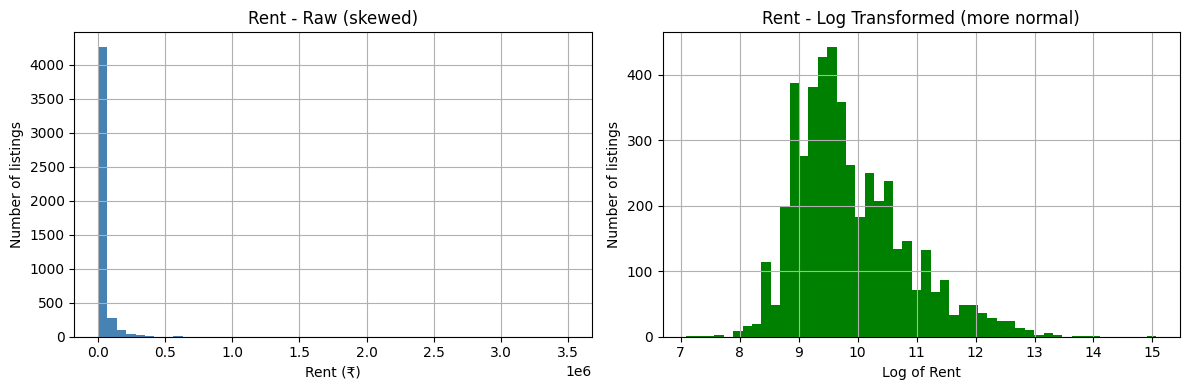

In [5]:
import matplotlib.pyplot as plt
# Step 1: Plot raw rent distribution
# A histogram shows how many rows fall into each price range
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df['Rent'].hist(bins=50, color='steelblue')
plt.title('Rent - Raw (skewed)')
plt.xlabel('Rent (₹)')
plt.ylabel('Number of listings')

# Step 2: Plot log-transformed rent
# np.log1p is log(value + 1) — the +1 is just a safety measure in case any value is 0
plt.subplot(1, 2, 2)
np.log1p(df['Rent']).hist(bins=50, color='green')
plt.title('Rent - Log Transformed (more normal)')
plt.xlabel('Log of Rent')
plt.ylabel('Number of listings')

plt.tight_layout()
plt.show()

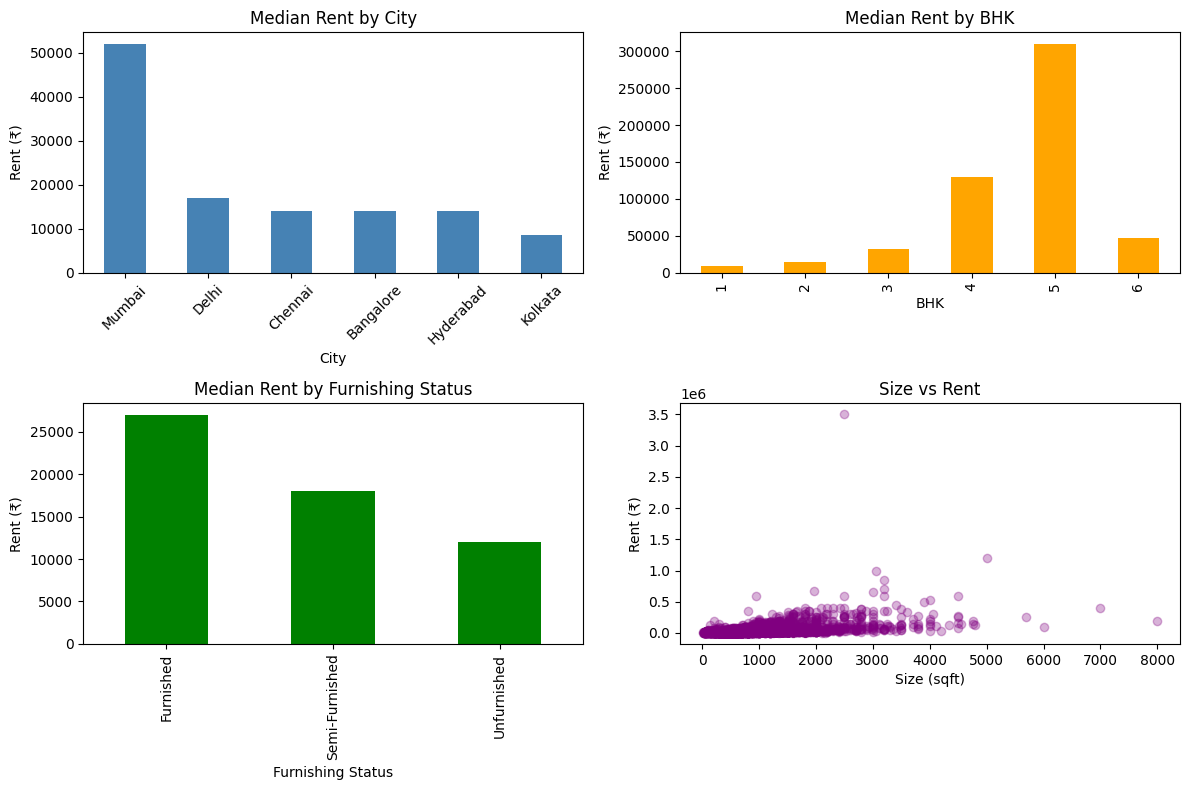

In [7]:
# How does rent vary by City?
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
df.groupby('City')['Rent'].median().sort_values(ascending=False).plot(kind='bar', color='steelblue')
plt.title('Median Rent by City')
plt.ylabel('Rent (₹)')
plt.xticks(rotation=45)

# How does rent vary by number of bedrooms (BHK)?
plt.subplot(2, 2, 2)
df.groupby('BHK')['Rent'].median().plot(kind='bar', color='orange')
plt.title('Median Rent by BHK')
plt.ylabel('Rent (₹)')

# How does rent vary by Furnishing Status?
plt.subplot(2, 2, 3)
df.groupby('Furnishing Status')['Rent'].median().plot(kind='bar', color='green')
plt.title('Median Rent by Furnishing Status')
plt.ylabel('Rent (₹)')

# Does Size (sqft) correlate with Rent?
plt.subplot(2, 2, 4)
plt.scatter(df['Size'], df['Rent'], alpha=0.3, color='purple')
plt.title('Size vs Rent')
plt.xlabel('Size (sqft)')
plt.ylabel('Rent (₹)')

plt.tight_layout()
plt.show()

In [8]:
# Check the Floor column — remember it's messy text like "1 out of 3"
print(df['Floor'].value_counts().head(20))

# Check how many unique localities there are
print(f"\nUnique localities: {df['Area Locality'].nunique()}")
print(f"Unique cities: {df['City'].nunique()}")

Floor
1 out of 2         379
Ground out of 2    350
2 out of 3         312
2 out of 4         308
1 out of 3         293
3 out of 4         239
Ground out of 3    209
1 out of 4         200
Ground out of 1    195
1 out of 1         134
2 out of 2         132
Ground out of 4    115
2 out of 5         106
3 out of 3          96
1 out of 5          87
4 out of 5          86
3 out of 5          84
4 out of 4          73
3 out of 7          32
5 out of 7          32
Name: count, dtype: int64

Unique localities: 2235
Unique cities: 6


In [17]:
import pandas as pd
import numpy as np

# Always start from the raw file — this resets df every time you rerun
df = pd.read_csv("../data/House_Rent_Dataset.csv")

# --- STEP 1: Parse the Floor column ---
def parse_floor(floor_str):
    try:
        parts = floor_str.split(' out of ')
        total = int(parts[1])
        current = parts[0]
        if current.lower() == 'ground':
            current = 0
        elif current.lower() == 'upper basement':
            current = -1
        elif current.lower() == 'lower basement':
            current = -2
        else:
            current = int(current)
        return current, total
    except:
        return None, None

df['Floor_Number'], df['Total_Floors'] = zip(*df['Floor'].apply(parse_floor))

# --- STEP 2: Drop columns we won't use ---
df = df.drop(columns=['Floor', 'Area Locality', 'Posted On'])

# --- STEP 3: Create log target ---
df['Rent_log'] = np.log1p(df['Rent'])

print("Cleaning done. Shape:", df.shape)
print(df.head(3))

Cleaning done. Shape: (4746, 12)
   BHK   Rent  Size   Area Type     City Furnishing Status  Tenant Preferred  \
0    2  10000  1100  Super Area  Kolkata       Unfurnished  Bachelors/Family   
1    2  20000   800  Super Area  Kolkata    Semi-Furnished  Bachelors/Family   
2    2  17000  1000  Super Area  Kolkata    Semi-Furnished  Bachelors/Family   

   Bathroom Point of Contact  Floor_Number  Total_Floors  Rent_log  
0         2    Contact Owner           0.0           2.0  9.210440  
1         1    Contact Owner           1.0           3.0  9.903538  
2         1    Contact Owner           1.0           3.0  9.741027  


In [31]:
# Feature Engineering — adding before encoding so these columns get included

# Floor ratio — how high up proportionally in the building
df['floor_ratio'] = df['Floor_Number'] / (df['Total_Floors'] + 1e-5)

# BHK per bathroom — captures layout quality
df['bhk_per_bathroom'] = df['BHK'] / (df['Bathroom'] + 1e-5)

print("New features added:")
print(df[['Floor_Number', 'Total_Floors', 'floor_ratio', 'BHK', 'Bathroom', 'bhk_per_bathroom']].head())

New features added:
   Floor_Number  Total_Floors  floor_ratio  BHK  Bathroom  bhk_per_bathroom
0           0.0           2.0     0.000000    2         2          0.999995
1           1.0           3.0     0.333332    2         1          1.999980
2           1.0           3.0     0.333332    2         1          1.999980
3           1.0           2.0     0.499998    2         1          1.999980
4           1.0           2.0     0.499998    2         1          1.999980


In [32]:
# These are all our text columns that need encoding
categorical_cols = ['Area Type', 'City', 'Furnishing Status', 
                    'Tenant Preferred', 'Point of Contact']

# pd.get_dummies does one hot encoding automatically
# drop_first=True drops one category per column to avoid redundancy
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df_encoded.shape)
print(df_encoded.columns.tolist())

(4746, 22)
['BHK', 'Rent', 'Size', 'Bathroom', 'Floor_Number', 'Total_Floors', 'Rent_log', 'floor_ratio', 'bhk_per_bathroom', 'Area Type_Carpet Area', 'Area Type_Super Area', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Kolkata', 'City_Mumbai', 'Furnishing Status_Semi-Furnished', 'Furnishing Status_Unfurnished', 'Tenant Preferred_Bachelors/Family', 'Tenant Preferred_Family', 'Point of Contact_Contact Builder', 'Point of Contact_Contact Owner']


In [33]:
from sklearn.model_selection import train_test_split

# Define features (X) and target (y)
# X = everything except Rent and Rent_log (those are what we're predicting)
X = df_encoded.drop(columns=['Rent', 'Rent_log'])
y = df_encoded['Rent_log']  # we predict the log version

# Split — 80% train, 20% test
# random_state=42 just means the split is reproducible (same split every time you run)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training rows: {X_train.shape[0]}")
print(f"Test rows: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")

Training rows: 3796
Test rows: 950
Features: 20


In [34]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# --- Fix: check where NaNs are ---
print("NaN counts:")
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

# --- Fix: fill NaNs with median of each column ---
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_test.median())

print("\nNaN values remaining:", X_train.isnull().sum().sum())

# --- Model 1: Linear Regression (baseline) ---
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

# --- Model 2: Random Forest ---
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# --- Evaluate both ---
def evaluate(name, y_true, y_pred):
    # Convert predictions back from log to actual ₹
    y_true_actual = np.expm1(y_true)
    y_pred_actual = np.expm1(y_pred)
    
    mae = mean_absolute_error(y_true_actual, y_pred_actual)
    rmse = np.sqrt(mean_squared_error(y_true_actual, y_pred_actual))
    
    print(f"\n{name}")
    print(f"  MAE  : ₹{mae:,.0f}")
    print(f"  RMSE : ₹{rmse:,.0f}")

evaluate("Linear Regression", y_test, lr_preds)
evaluate("Random Forest", y_test, rf_preds)

NaN counts:
Floor_Number    4
Total_Floors    4
floor_ratio     4
dtype: int64

NaN values remaining: 0

Linear Regression
  MAE  : ₹11,107
  RMSE : ₹30,517

Random Forest
  MAE  : ₹10,922
  RMSE : ₹36,196


In [42]:
%pip install xgboost

  Using cached xgboost-3.3.0-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.3.0-py3-none-win_amd64.whl (69.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [43]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
evaluate("XGBoost", y_test, xgb_preds)


XGBoost
  MAE  : ₹11,183
  RMSE : ₹37,346


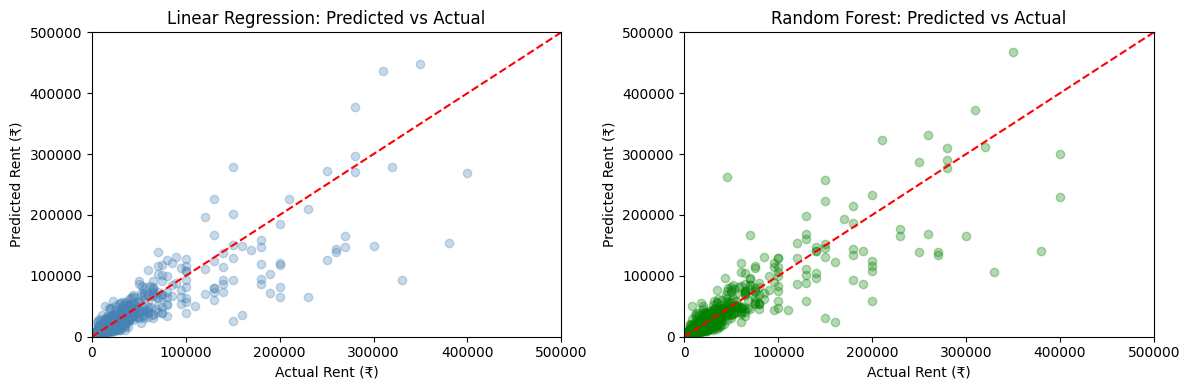

In [44]:
plt.figure(figsize=(12, 4))

# Linear Regression: predicted vs actual
plt.subplot(1, 2, 1)
plt.scatter(np.expm1(y_test), np.expm1(lr_preds), alpha=0.3, color='steelblue')
plt.plot([0, 500000], [0, 500000], 'r--')  # perfect prediction line
plt.title('Linear Regression: Predicted vs Actual')
plt.xlabel('Actual Rent (₹)')
plt.ylabel('Predicted Rent (₹)')
plt.xlim(0, 500000)
plt.ylim(0, 500000)

# Random Forest: predicted vs actual
plt.subplot(1, 2, 2)
plt.scatter(np.expm1(y_test), np.expm1(rf_preds), alpha=0.3, color='green')
plt.plot([0, 500000], [0, 500000], 'r--')  # perfect prediction line
plt.title('Random Forest: Predicted vs Actual')
plt.xlabel('Actual Rent (₹)')
plt.ylabel('Predicted Rent (₹)')
plt.xlim(0, 500000)
plt.ylim(0, 500000)

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

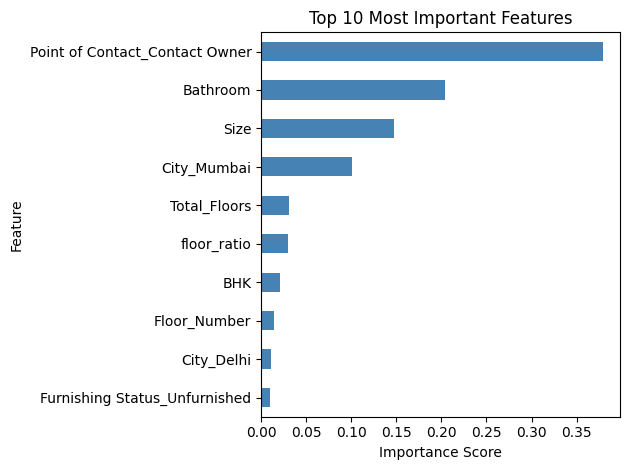

                           Feature  Importance
19  Point of Contact_Contact Owner    0.379163
2                         Bathroom    0.203479
1                             Size    0.147413
13                     City_Mumbai    0.101194
4                     Total_Floors    0.031371
5                      floor_ratio    0.029284
0                              BHK    0.021359
3                     Floor_Number    0.014049
10                      City_Delhi    0.011428
15   Furnishing Status_Unfurnished    0.010194


In [36]:
# Random Forest gives us feature importance scores automatically
# Higher score = that feature influenced predictions more

importances = rf.feature_importances_
feature_names = X_train.columns

# Put into a dataframe and sort
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot top 10 most important features
plt.figure(figsize=(10, 6))
feat_imp.head(10).plot(
    kind='barh', 
    x='Feature', 
    y='Importance', 
    color='steelblue',
    legend=False
)
plt.title('Top 10 Most Important Features')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()  # most important at top
plt.tight_layout()
plt.show()

print(feat_imp.head(10))

In [45]:
import pickle
with open('model.pkl', 'wb') as f:
    pickle.dump(rf, f)

with open('columns.pkl', 'wb') as f:
    pickle.dump(X_train.columns.tolist(), f)

print("Model saved!")
print(f"Features: {X_train.columns.tolist()}")

Model saved!
Features: ['BHK', 'Size', 'Bathroom', 'Floor_Number', 'Total_Floors', 'floor_ratio', 'bhk_per_bathroom', 'Area Type_Carpet Area', 'Area Type_Super Area', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Kolkata', 'City_Mumbai', 'Furnishing Status_Semi-Furnished', 'Furnishing Status_Unfurnished', 'Tenant Preferred_Bachelors/Family', 'Tenant Preferred_Family', 'Point of Contact_Contact Builder', 'Point of Contact_Contact Owner']
